# Trabajo Práctico #2
## Simulación de Modelos en Derivadas Parciales
## UdeMM - Ingeniería en Sistemas

* Profesor: Dr. Alejandro Gronskis
* Alumno: Daniel Ise
* Legajo: 28547
* Octubre, 2026

# Grilla de cálculo (stencil)

## Consigna
Asocie cada uno de los siguientes _stencils_ a su correspondiente esquema de cálculo.

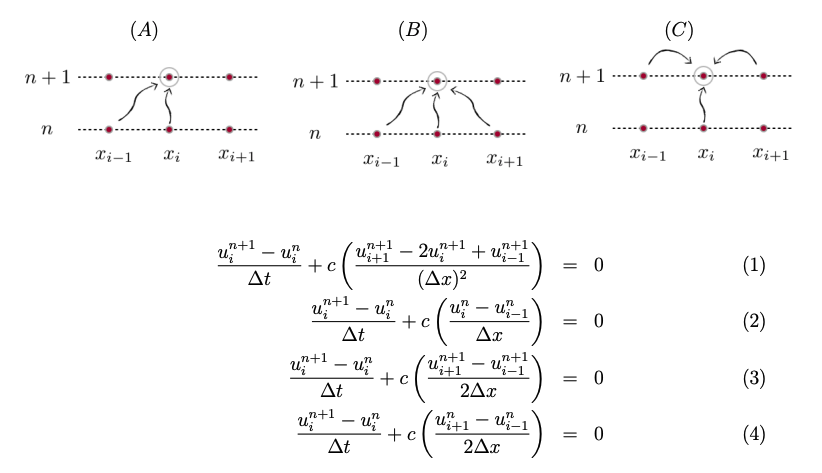

## Respuesta
El _stencil_ A corresponde a la expresión $2$.
Puesto que los términos que multiplican a la velocidad $c$ son $u_i^n$ y $u_{i-1}^n$.
Tal y como muestra el _stencil_ A.

El _stencil_ B, por su parte, se corresponde con la expresión 4.
Elección que justifica en la presencia de los términos  $u_i^n$,
$u_{i+1}^n$ y $u_{i-1}^n$, 
que coinciden con los mostrados en la grilla de cálculo.

Por último, la grilla de cálculo C, por los términos $u_{i-1}^{n+1}$,
$u_{i}^{n}$ y $u_{i+1}^{n+1}$, se corresponde con la expresión 3.

# Solución numérica

## Estabilidad

### Consigna

Se considera un esquema de adelanto en tiempo y atraso en espacio para
discretizar un problema de advección lineal con un coeficiente
convectivo $c=4$ y un tamaño de paso espacial $\Delta x=2$. 
Determine el valor máximo del paso de tiempo $\Delta t$
que permita asegurar la estabilidad de la solución.

#### Respuesta

La estabilidad del esquema de discretización depende de la condición CFL (Courant-Friedrichs-Lewy):

$$
\sigma = \frac{c \Delta t}{\Delta x} \leq 1
$$

Como $c=4$ y $\Delta x=2$:

$$
\frac{4 \Delta t}{2} \leq 1
$$
$$
\Delta t \leq \frac{1}{2}
$$

Por lo tanto, concluímos que, 
para asegurar la estabilidad de la solución,
se debe cumplir la condición $\Delta t \leq \frac{1}{2}$.

## SymPy

### Consigna

Empleando `SymPy` evalúe la derivada parcial con respecto a $x$ 
de la expresión siguiente en $x=2.2$:

$$
\frac{\cos^2(x)\sin^3(x)}{4x^5\exp(x)}
$$

### Respuesta

En primer lugar, importamos las librerías.

In [1]:
import numpy as np
from sympy import symbols, cos, sin, exp, init_printing, diff, nsolve

Especificamos la salida en formato $\LaTeX$:

In [2]:
init_printing(use_unicode=True)

Fijamos `x` como variable simbólica para la función:

In [3]:
x = symbols('x')
x

Planteamos la expresión en `f`:

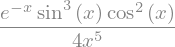

In [4]:
f = (cos(x)**2*sin(x)**3)/(4*x**5)/(exp(x))
f

Operamos la derivada:

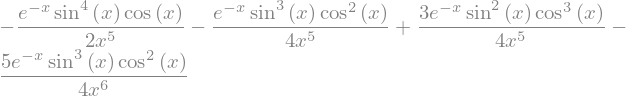

In [5]:
fprime = f.diff(x)
fprime

Y por último, evaluamos $f'(x)$ en $x=2.2$:

In [6]:
fprime.subs(x, 2.2)

# Trabajo de código: Flujo de tráfico

## Respuesta

Para discretizar la ecuación de advección no lineal 
de la densidad del tráfico 
$\frac{\partial \rho}{\partial t} + \frac{\partial F}{\partial x} = 0$ 
usamos un esquema _forward_ en tiempo, _backward_ en espacio,
resultando en:

$$
\frac{\rho_{i}^{n + 1} - \rho_i^n}{\Delta t} 
+ \frac{F_i^n - F_{i-1}^n}{\Delta x}
= 0
$$

Por lo tanto, despejando $\rho_i^{n+1}$:

$$
\rho_i^{n+1} = \rho_i^n - \frac{\Delta t}{\Delta x} (F_i^n - F_{i-1}^n)
$$

### Simulación Parte A

Planteamos los parámetros:

In [7]:
nx = 51
L = 11
dx = L / (nx - 1)
dt = .001

La condición inicial:

In [8]:
x = np.linspace(0, L, nx)
rho0 = np.ones(nx) * 10
rho0[10:20] = 50

Y las expresiones para la velocidad y el flujo, proporcionadas por el problema:

In [9]:
def V(rho, v_max=80, rho_max=250):
    """
    Determinar la velocidad, dado un valor de rho y los parámetros iniciales
    """
    return v_max * (1 - rho/rho_max)

def F(rho, v_max=80, rho_max=250):
    """
    Determinar el flujo, dado un valor de rho, con parámetros iniciales por defeto.
    """
    return v_max * rho * (1 - rho/rho_max)

1. Para encontrar la velocidad mínima en $t=0$, podemos operar $V(\rho)$ con $\rho$ máxima, esto es, $\rho = 50$:

In [10]:
V(50)

La velocidad mínima en $t=0$ es $64 km/h$. Gráficamente:

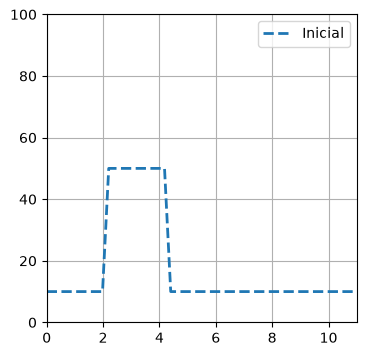

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

2. Para V en $t=3 min$, primero debemos determinar `nt`:

In [12]:
# dt * 60 min = dt en minutos
dt_min = dt * 60
# dt_min * nt = 3 min => nt = 3 min / dt_min
nt = int(3 / dt_min)
nt

Con `nt` calculado, planteamos el `for-loop`:

In [13]:
rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 10

v_3min = V(rho)

Gráficamente:

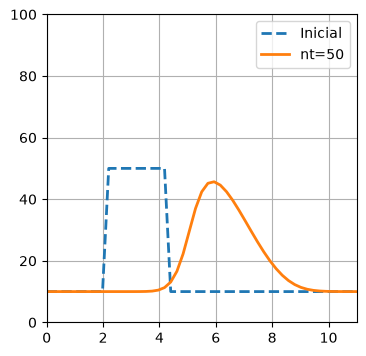

In [14]:
plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.plot(x,rho,label=f'nt={50}',
            color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

Por último, con la función `mean` de `NumPy` obtenemos la velocidad media:

In [15]:
np.mean(v_3min)

La velocidad media con $t=3min$ sería $\approx 74.29 km/h$

3. Para determinar a los 6 minutos, deberíamos de seguir el mismo razonamiento, ajustando `nt`:

In [16]:
nt = int(6 / dt_min)
nt

In [17]:
rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 10

v6min = V(rho)
np.min(v6min)

La velocidad mínima en $t=6$ sería $\approx 67.6 km/h$

Gráficamente:

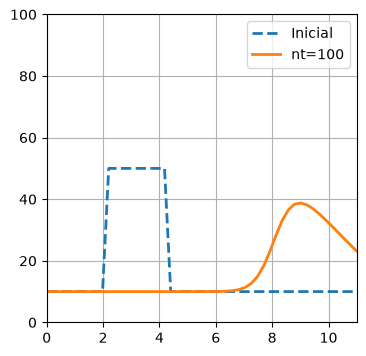

In [18]:
plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.plot(x,rho,label=f'nt={nt}',
            color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

La inestabilidad aparece con el incumplimiento de la condición CFL, i.e., $c\Delta t \geq \Delta x$. Podemos incumplirla cambiando la grilla o incrementando el tamaño de los pasos en el tiempo $\Delta t$:

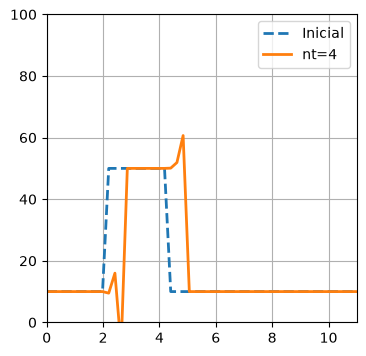

In [19]:
# Planteamos un dt que incumpla CFL
dt = .004
nt = int(1.0 / (dt * 60.0))

rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 10

plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.plot(x,rho,label=f'nt={nt}',
            color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

### Simulación Parte B

Para la simulación de la Parte B debemos cambiar las condiciones iniciales y algunos parámetros.

In [20]:
nx = 51
L = 11
dt = .001
x = np.linspace(0, L, nx)
rho0 = np.ones(nx) * 20
rho0[10:20] = 50

def V(rho, v_max=136, rho_max=250):
    """
    Determinar la velocidad, dado un valor de rho y los parámetros iniciales
    """
    return v_max * (1 - rho/rho_max)

def F(rho, v_max=136, rho_max=250):
    """
    Determinar el flujo, dado un valor de rho, con parámetros iniciales por defeto.
    """
    return v_max * rho * (1 - rho/rho_max)

1. Mínima en $t=0$

In [21]:
V(50)

La velocidad mínima en $t=0$ es $\approx 109 km/h$. El gráfico correspondiente es:

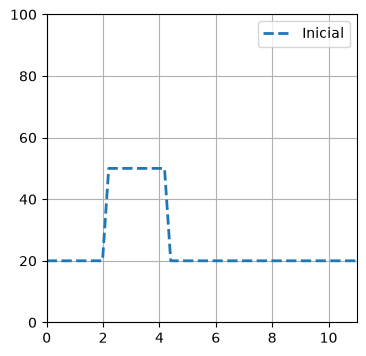

In [22]:
plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

2. Media en $t=3$, con `nt=50`:

In [23]:
nt = 50
rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 20

v_3min = V(rho)
np.mean(v_3min)

Velocidad media para $t=3min$ es $121.93km/h$.

La representación gráfica correspondiente:

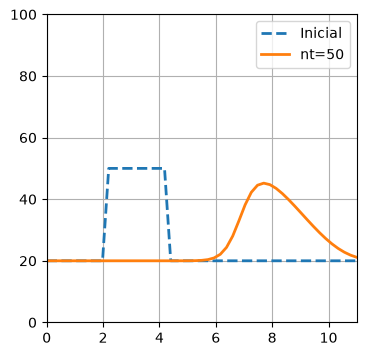

In [24]:
plt.figure(figsize=(4.0,4.0))
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.plot(x,rho,label=f'nt={nt}',
            color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);

3. Mínima con $t=6$, siendo `nt=100`, como se determinó con anterioridad:

In [25]:
nt = 100
rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 20

v6min = V(rho)
np.min(v6min)

La mínima sería $123.88km/h$.

Una situación de inestabilidad aparece con el incumplimiento de la condición CFL, i.e., $c\Delta t \geq \Delta x$, en este caso, por incrementar $\Delta t$:

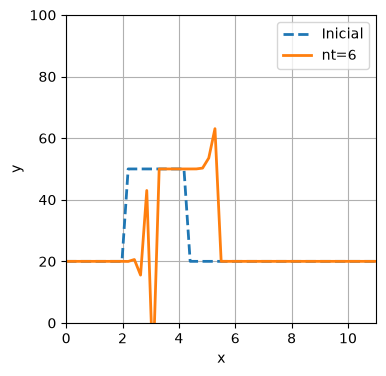

In [26]:
# dt >= 11/50/136 >= .0016...
# Planteamos un dt que incumpla CFL
dt = .0025
nt = int(1.0 / (dt * 60.0))

rho = rho0.copy()
for n in range(1, nt):
    rhon = rho.copy()
    rho[1:] = rhon[1:] - dt/dx * (F(rhon[1:]) - F(rhon[:-1]))
    rho[0] = 20

plt.figure(figsize=(4.0,4.0))
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.plot(x,rho0,label='Inicial',
            color='C0',linestyle='--',linewidth=2)
plt.plot(x,rho,label=f'nt={nt}',
            color='C1',linestyle='-',linewidth=2)
plt.legend()
plt.xlim(0.0,L)
plt.ylim(0.0,100);